# Import libraries and data

## Libraries and functions

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import geopandas as gpd
import networkx as nx
import csv
import xml.etree.ElementTree as ET
from scipy.spatial import KDTree
from scipy.spatial import cKDTree
import pickle
import folium
from shapely.geometry import LineString
from shapely.geometry import box
import contextily as ctx


from Tool import clean_speed, fill_tracks, clean_elec, from_df_to_geodf, neighbour_gauge, final_gauge, haversine_distance, is_important_component

## Inputs

In [4]:
#Change inputs here if needed
rail_data = "data/uk_railways_osm.gpkg"
Train_Planning_file = "data/TrainPlanningRules.xml"
Stops = "data/Stops.csv"
loading_gauge = "data/loading_gauge.geojson"
nodes_file = "nodes.csv"
STANOX_TIPLOC = "data/STANOX_TIPLOC.csv"

## Import of the datasets and conversion into a csv file

In [5]:
gdf = gpd.read_file(rail_data)

gdf['geometry_wkt'] = gdf['geometry'].apply(lambda x: x.wkt)

gdf['start_lon'] = gdf['geometry'].apply(lambda x: x.coords[0][0])
gdf['start_lat'] = gdf['geometry'].apply(lambda x: x.coords[0][1])
gdf['end_lon'] = gdf['geometry'].apply(lambda x: x.coords[-1][0])
gdf['end_lat'] = gdf['geometry'].apply(lambda x: x.coords[-1][1])

if 'other_tags' in gdf.columns:
    gdf['other_tags'] = gdf['other_tags'].astype(str)

#Not compatible with geopandas
df_rail = pd.DataFrame(gdf.drop(columns=['geometry']))

df_rail.to_csv("complete_railway_network.csv", index=False, sep=';', encoding='utf-8')

## Clean this dataset

In [6]:
df_rail = df_rail[df_rail['railway'].isin(['rail', 'service', 'yard', 'siding', 'industrial', 'disused'])]

### Clean speed format and fill missing values with 60 mph.

In [7]:
df_rail = clean_speed(df_rail)

### Here, we consider to fill the branch or industrial types with 1 track, the others with 2 tracks.

In [8]:
df_rail = fill_tracks(df_rail)
df_rail["tracks"] = df_rail["tracks"].astype(int)

### We will simplify different type of electrification

In [9]:
df_rail['elec_type'] = df_rail.apply(clean_elec, axis=1)

In [10]:
df_rail.columns

Index(['osm_id', 'name', 'highway', 'waterway', 'aerialway', 'barrier',
       'man_made', 'railway', 'usage', 'electrified', 'frequency', 'gauge',
       'maxspeed', 'operator', 'railway_aws', 'railway_tpws', 'ref', 'voltage',
       'layer', 'tracks', 'passenger_lines', 'foot', 'lit', 'segregated',
       'smoothness', 'surface', 'width', 'bicycle', 'z_order', 'other_tags',
       'geometry_wkt', 'start_lon', 'start_lat', 'end_lon', 'end_lat',
       'elec_type'],
      dtype='object')

In [11]:
to_drop = [
    "highway", "waterway", "aerialway", "barrier", "man_made",
    "railway_aws", "railway_tpws", "ref", "layer", "foot", "lit",
    "segregated", "smoothness", "surface", "width", "bicycle",
    "z_order", "other_tags"
]

df_rail = df_rail.drop(columns=[c for c in to_drop if c in df_rail.columns])

In [12]:
print("\n Stats for 'electrified':")
print(df_rail['electrified'].value_counts(dropna=False))


 Stats for 'electrified':
electrified
no                       43896
contact_line             26848
rail                     13110
None                      8157
4th_rail                   283
proposed                   242
contact_line;rail          157
contact_line;4th_rail        9
yes                          4
0                            1
construction                 1
Name: count, dtype: int64


In [13]:
df_rail.head()

,osm_id,name,railway,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,passenger_lines,geometry_wkt,start_lon,start_lat,end_lon,end_lat,elec_type
0,740,Cross-City Line,rail,branch,contact_line,50,1435,45.0,Network Rail,25000,1,None,"LINESTRING (-1.8178905 52.5700974, -1.8179287 ...",-1.817891,52.570097,-1.822176,52.565950,Overhead
1,2148,Cross-City Line,rail,branch,contact_line,50,1435,45.0,Network Rail,25000,1,None,"LINESTRING (-1.873028 52.5054182, -1.8726964 5...",-1.873028,52.505418,-1.871725,52.504113,Overhead
3,3413,North Clyde Line,rail,main,contact_line,50,1435,50.0,Network Rail,25000,2,2,"LINESTRING (-4.3258776 55.8827209, -4.3255873 ...",-4.325878,55.882721,-4.323074,55.882447,Overhead
4,3417,North Clyde Line,rail,main,contact_line,50,1435,40.0,Network Rail,25000,2,2,"LINESTRING (-4.3138852 55.8776742, -4.3139865 ...",-4.313885,55.877674,-4.310577,55.870938,Overhead
5,3471,Midland Main Line,rail,main,contact_line,50,1435,90.0,Network Rail,25000,1,4,"LINESTRING (-0.4950811 51.9681192, -0.4951938 ...",-0.495081,51.968119,-0.495194,51.963738,Overhead


In [14]:
print("Values in 'tracks':")
print(df_rail['tracks'].unique())
print(df_rail['tracks'].value_counts(dropna=False))

Values in 'tracks':
[1 2 4 5 6 3]
tracks
2    67897
1    23266
4     1144
6      301
3       51
5       49
Name: count, dtype: int64


In [15]:
len(df_rail)

92708

# Cleaning of the dataset

## Load the loading gauge dataset

In [16]:
#Load datasets

gdf_rail = from_df_to_geodf(df_rail)
gdf_loading_gauge = gpd.read_file(loading_gauge)

#Join and check the neighbours to apply to missing loading gauges
df_complete = neighbour_gauge(gdf_rail, gdf_loading_gauge)

#If no neighboutrs, check the voltage to find the loading gauge
df_complete['loading_gauge_final'] = df_complete.apply(final_gauge, axis=1)

#Spread of different loading gauges
print(df_complete['loading_gauge_final'].value_counts())

c:\Users\Administrateur\Documents\3A\Internship\resilience_freight_train_UK\Tool.py:92: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  unknown['geom_buffer'] = unknown.geometry.buffer(0.00001)


loading_gauge_final
6.0     51062
10.0    26553
7.0     12538
8.0      1590
12.0      790
1.0       117
9.0        58
Name: count, dtype: int64


## Clean this datset

### Outliers : there are "W1" gauges that need to be removed

In [17]:
#We replace these W1 values by W6 values
df_complete.loc[df_complete['loading_gauge_final'] < 6, 'loading_gauge_final'] = 6
print(df_complete['loading_gauge_final'].value_counts().sort_index())

df_complete.to_csv("Final_dataframe_rail.csv", index=False)

loading_gauge_final
6.0     51179
7.0     12538
8.0      1590
9.0        58
10.0    26553
12.0      790
Name: count, dtype: int64


In [18]:
df_complete = df_complete.drop(columns=['railway', 'index_right', 'loading_gauge_val'])

## Add the distance between two nodes

In [19]:
df_complete['distance'] = haversine_distance(df_complete["start_lat"],df_complete["start_lon"],df_complete["end_lat"],df_complete["end_lon"])
df_complete['min_travel_time'] = df_complete['distance'] / df_complete['maxspeed']

In [20]:
df_complete.head()

,osm_id,name,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,...,geometry_wkt,start_lon,start_lat,end_lon,end_lat,elec_type,geometry,loading_gauge_final,distance,min_travel_time
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,"LINESTRING (-1.8178905 52.5700974, -1.8179287 ...",-1.817891,52.570097,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,"LINESTRING (-1.873028 52.5054182, -1.8726964 5...",-1.873028,52.505418,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346
3,3413,North Clyde Line,main,contact_line,50,1435,50.0,Network Rail,25000,2,...,"LINESTRING (-4.3258776 55.8827209, -4.3255873 ...",-4.325878,55.882721,-4.323074,55.882447,Overhead,"LINESTRING (-4.32588 55.88272, -4.32559 55.882...",10.0,0.110298,0.002206
4,3417,North Clyde Line,main,contact_line,50,1435,40.0,Network Rail,25000,2,...,"LINESTRING (-4.3138852 55.8776742, -4.3139865 ...",-4.313885,55.877674,-4.310577,55.870938,Overhead,"LINESTRING (-4.31389 55.87767, -4.31399 55.876...",10.0,0.482767,0.012069
5,3471,Midland Main Line,main,contact_line,50,1435,90.0,Network Rail,25000,1,...,"LINESTRING (-0.4950811 51.9681192, -0.4951938 ...",-0.495081,51.968119,-0.495194,51.963738,Overhead,"LINESTRING (-0.49508 51.96812, -0.49519 51.96374)",10.0,0.302781,0.003364


## Upload a file with names for train stations

In [21]:
with open(nodes_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "tiploc", "name"])

    for event, elem in ET.iterparse(Train_Planning_file, events=("end",)):
        if elem.tag == "TTPRLocation":
            
            writer.writerow([
                elem.attrib.get("Id"),
                elem.attrib.get("Tiploc"),
                elem.attrib.get("Description")
            ])
            
            elem.clear()

## Clean this dataset

In [22]:
df_nodes = pd.read_csv(nodes_file)

#Delete row without ID
df_nodes = df_nodes.dropna(subset=['id'])
df_nodes = df_nodes.drop_duplicates()

#Clean the str and make sure any blank space is there
df_nodes['tiploc'] = df_nodes['tiploc'].astype(str).str.strip()
df_nodes['name'] = df_nodes['name'].astype(str).str.strip()

invalid_values = ["unknown", "none", "nan"]

df_nodes = df_nodes[
    ~df_nodes.drop(columns=["id"])
      .apply(lambda col: col.astype(str).str.strip().str.lower())
      .isin(invalid_values)
      .all(axis=1)
]


df_nodes.to_csv("nodes_clean.csv", index=False)

print("Number of remaining nodes: ", len(df_nodes))

Number of remaining nodes:  12107


In [23]:
df_nodes.head()

,id,tiploc,name
2,3.0,AACHEN,Aachen
3,4.0,ABCWM,Abercwmboi
4,5.0,ABDAPEN,Penywaun
5,6.0,ABDARE,Aberdare
6,7.0,ABDATRE,Trecynon


## Load datsaset with locations and merge with the names dataset

In [24]:
df_lon_lat = pd.read_csv("data/stations.csv")

print("Number of nodes remaining (nodes) : ", len(df_nodes))
print("Number of nodes remaining (lon_lat) : ", len(df_lon_lat))

df_name_loc = pd.merge(
    df_nodes, 
    df_lon_lat, 
    left_on='name', 
    right_on='stationName', 
    how='left'
)

df_name_loc.head(10)

Number of nodes remaining (nodes) :  12107
Number of nodes remaining (lon_lat) :  2605


,id,tiploc,name,stationName,lat,long,crsCode,iataAirportCode,constituentCountry
0,3.0,AACHEN,Aachen,NaN,NaN,NaN,NaN,NaN,NaN
1,4.0,ABCWM,Abercwmboi,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,ABDAPEN,Penywaun,NaN,NaN,NaN,NaN,NaN,NaN
3,6.0,ABDARE,Aberdare,Aberdare,51.715019,-3.443130,ABA,NaN,wales
4,7.0,ABDATRE,Trecynon,NaN,NaN,NaN,NaN,NaN,NaN
5,8.0,ABDO,Aberdour,Aberdour,56.054646,-3.300575,AUR,NaN,scotland
6,9.0,ABDVY,Aberdovey,Aberdovey,52.543934,-4.057118,AVY,NaN,wales
7,10.0,ABER,Aber,Aber,51.575363,-3.230890,ABE,NaN,wales
8,11.0,ABGLELE,Abergele & Pensarn,Abergele & Pensarn,53.294758,-3.581343,AGL,NaN,wales
9,12.0,ABGNWYN,Abergynolwyn,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
print(len(df_name_loc))
df_name_loc = df_name_loc.drop(columns=['stationName', 'iataAirportCode', 'constituentCountry'])

12107


In [26]:
df_name_loc.head()

,id,tiploc,name,lat,long,crsCode
0,3.0,AACHEN,Aachen,NaN,NaN,NaN
1,4.0,ABCWM,Abercwmboi,NaN,NaN,NaN
2,5.0,ABDAPEN,Penywaun,NaN,NaN,NaN
3,6.0,ABDARE,Aberdare,51.715019,-3.44313,ABA
4,7.0,ABDATRE,Trecynon,NaN,NaN,NaN


## Add the Engineer Line Reference (ELR) in order to identify easily the line

In [27]:
elr = gpd.read_file("data/ELR/NetworkReferenceLines.shp")
elr_buff = elr.to_crs(4326).copy()
elr_buff["geometry"] = elr_buff.geometry.buffer(0.0001)
elr


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_18400\2230585469.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  elr_buff["geometry"] = elr_buff.geometry.buffer(0.0001)


,OBJECTID,ASSETID,L_LINK_ID,L_SYSTEM,ELR,L_M_FROM,L_M_TO,SHAPE_LEN,geometry
0,1650,9003000263,232,M,CNC,-0.0055,0.0891,899.318917,"LINESTRING Z (258538.418 661238.192 0, 258545...."
1,1651,9003001307,1191,M,WCL,0.1758,2.1706,3170.461977,"LINESTRING Z (521077.898 183246.059 0, 521052...."
2,1652,9003001178,1076,M,SSK1,26.1589,39.0242,19691.905626,"LINESTRING Z (465068.728 521387.373 0, 465077...."
3,1653,9003001388,1260,M,YJP,-0.0350,1.0954,2797.307199,"LINESTRING Z (356982.337 114059.032 0, 356989...."
4,1654,9003000952,873,M,PEH,0.0849,13.0960,21015.381545,"LINESTRING Z (413793.018 416380.012 0, 413729...."
...,...,...,...,...,...,...,...,...,...
1585,5131,9003001637,1694,M,GRC1,-0.0068,0.0723,732.035182,"LINESTRING Z (441392.094 406550.649 0, 441449...."
1586,5132,9003001623,1680,M,CMP,188.0727,188.1215,446.568578,"LINESTRING Z (385412.469 397552.006 0, 385361...."
1587,5133,9003001609,1718,M,RET,-0.0016,0.0927,863.140513,"LINESTRING Z (193288.191 59949.545 0, 193314.5..."
1588,5134,9003001618,1673,M,SWX,-0.0012,0.0784,728.586613,"LINESTRING Z (503416.196 172077.673 0, 503378...."


In [28]:
df_final = gpd.sjoin(
    df_complete,
    elr_buff[["ELR", "L_LINK_ID", "geometry"]],
    how="left",
    predicate="intersects"
)

print(df_final["ELR"].isna().mean())

print(df_final.columns)
print(df_name_loc.columns)

0.1499253041189443
Index(['osm_id', 'name', 'usage', 'electrified', 'frequency', 'gauge',
       'maxspeed', 'operator', 'voltage', 'tracks', 'passenger_lines',
       'geometry_wkt', 'start_lon', 'start_lat', 'end_lon', 'end_lat',
       'elec_type', 'geometry', 'loading_gauge_final', 'distance',
       'min_travel_time', 'index_right', 'ELR', 'L_LINK_ID'],
      dtype='object')
Index(['id', 'tiploc', 'name', 'lat', 'long', 'crsCode'], dtype='object')


In [29]:
df_final.to_csv("OSM_cleaned_data.csv", index=False, sep=';', encoding='utf-8')

In [30]:
df_final.head()

,osm_id,name,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,...,end_lon,end_lat,elec_type,geometry,loading_gauge_final,distance,min_travel_time,index_right,ELR,L_LINK_ID
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520,877.0,CBR2,179.0
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520,750.0,ALC2,19.0
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346,497.0,ALC1,18.0
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346,88.0,PBJ,861.0
3,3413,North Clyde Line,main,contact_line,50,1435,50.0,Network Rail,25000,2,...,-4.323074,55.882447,Overhead,"LINESTRING (-4.32588 55.88272, -4.32559 55.882...",10.0,0.110298,0.002206,529.0,YKR,1261.0


# Construction of the graph

In [31]:
G = nx.Graph()

for _, row in df_name_loc.iterrows():

    node_id = row["tiploc"] if pd.notna(row["tiploc"]) else row["id"]

    G.add_node(
        node_id,
        type="station",
        name=row["name"],
        lat=row["lat"],
        lon=row["long"],
        crs=row["crsCode"],
    )

for _, row in df_final.iterrows():

    start = (row.start_lon, row.start_lat)
    end = (row.end_lon, row.end_lat)

    G.add_node(start, type="osm_point", lon=row.start_lon, lat=row.start_lat)
    G.add_node(end, type="osm_point", lon=row.end_lon, lat=row.end_lat)

    G.add_edge(
        start,
        end,
        distance=row["distance"],
        maxspeed=row["maxspeed"],
        loading_gauge=row["loading_gauge_final"],
        electrified=row["elec_type"],
        gauge=row["gauge"],
        tracks=row["tracks"],
        usage=row["usage"],
        elr=row["ELR"]
    )


#We merge the two dataframe into a graph
osm_nodes = np.array([node for node in G.nodes if isinstance(node, tuple)])

for _, row in df_name_loc.iterrows():

    station_id = row["tiploc"] if pd.notna(row["tiploc"]) else row["id"]
    station_point = np.array([row["long"], row["lat"]])

    #We aggregagte the nearest osm node to the tnode station
    dists = np.linalg.norm(osm_nodes - station_point, axis=1)
    nearest = tuple(osm_nodes[np.argmin(dists)])

    G.add_edge(station_id, nearest, type="station_link")


## Add STANOX attributes to the graph

In [32]:
df_STAN_TIP = pd.read_csv("data/STANOX_TIPLOC.csv", sep=",")
df_STAN_TIP["STANOX"] = (
    df_STAN_TIP["STANOX"]
    .astype(str)
    .str.strip()
    .replace("", None)
    .apply(lambda x: x.zfill(5) if x is not None else None)
)

stanox_map = df_STAN_TIP.set_index("TIPLOC")["STANOX"].to_dict()

for n, d in G.nodes(data=True):
    if d.get("type") == "station":
        tiploc = n
        d["stanox"] = stanox_map.get(tiploc)

In [33]:
stations = [n for n, d in G.nodes(data=True) if d.get("type")=="station"]
[(n, G.nodes[n].get("stanox")) for n in stations[:10]]

[('AACHEN', '00005'),
 ('ABCWM', '78128'),
 ('ABDAPEN', None),
 ('ABDARE', '78100'),
 ('ABDATRE', None),
 ('ABDO', '03295'),
 ('ABDVY', '64409'),
 ('ABER', '78371'),
 ('ABGLELE', '40073'),
 ('ABGNWYN', None)]

## Look at the graph attributes

In [34]:
print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())


Nodes : 119337
Edges : 104253


In [35]:
stations = [n for n, d in G.nodes(data=True) if d.get("type") == "station"]
print("Stations :", len(stations))


Stations : 11696


### Check whether some parts are isolated

In [36]:
nx.number_connected_components(G)

16874

In [37]:
distances = [d["distance"] for _,_,d in G.edges(data=True) if "distance" in d]
pd.Series(distances).describe()

count    92556.000000
mean         0.248679
std          0.501591
min          0.000000
25%          0.022690
50%          0.080016
75%          0.252066
max         15.837627
dtype: float64

In [38]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
print("Number of components in the graph :", len(components))
print("Size of the largest component :", len(components[0]))

Number of components in the graph : 16874
Size of the largest component : 73648


## Components to reconnect to the network

In [39]:
#Number of components ordered and with more than 20 nodes
components = list(nx.connected_components(G))
components_sorted = sorted(components, key=len, reverse=True)
components_filtered = [c for c in components_sorted if len(c) >= 20]
print(f"Total number of components : {len(components_sorted)}")

#Main component
main_component = components_filtered[0]
main_coords = np.array([n for n in main_component if isinstance(n, tuple)])
main_tree = KDTree(main_coords)

#Check if each component needs to be kept  or rejected
results = []

for idx, comp in enumerate(components_filtered):
    keep = is_important_component(G, comp, stations, main_coords, main_tree)
    results.append((idx, len(comp), keep))

for idx, size, keep in results:
    status = "KEPT" if keep else "REJECTED"

kept = sum(1 for _,_,k in results if k)
print("\nAfter cleaning, we have kept :", kept, "components")

Total number of components : 16874

After cleaning, we have kept : 86 components


## Distribution of node sizes components

In [40]:
sizes_kept = [len(components_filtered[idx]) 
              for idx, _, keep in results if keep]

print("Min size :", np.min(sizes_kept))
print("Max size :", np.max(sizes_kept))
print("Average size :", np.mean(sizes_kept))

hist = {}
for s in sizes_kept:
    bucket = (s // 20) * 20
    hist[bucket] = hist.get(bucket, 0) + 1

print("\nDistribution of remaining components :")
for k in sorted(hist):
    print(f"{k:3d}–{k+19:3d} : {hist[k]}")

Min size : 20
Max size : 73648
Average size : 909.3953488372093

Distribution of remaining components :
 20– 39 : 57
 40– 59 : 19
 60– 79 : 2
 80– 99 : 1
100–119 : 1
120–139 : 2
160–179 : 1
540–559 : 1
780–799 : 1
73640–73659 : 1


## Adding the disconnected components to the main component and linking them

In [41]:
kept_components = [
    comp for idx, comp in enumerate(components_filtered)
    if results[idx][2]
]

In [42]:
G_clean = nx.Graph()

for comp in kept_components:
    for n in comp:
        if isinstance(n, tuple) and len(n) == 2:
            G_clean.add_node(n, **G.nodes[n])

    for u, v in G.subgraph(comp).edges():
        if isinstance(u, tuple) and isinstance(v, tuple):
            G_clean.add_edge(u, v, **G[u][v])

In [43]:
component_trees = []

for idx, comp in enumerate(kept_components):
    coords = np.array([n for n in comp if isinstance(n, tuple)])
    tree = cKDTree(coords)
    component_trees.append((idx, coords, tree))

In [ ]:
connections = []

for i, (idx_i, coords_i, tree_i) in enumerate(component_trees):
    for j, (idx_j, coords_j, tree_j) in enumerate(component_trees):
        if j <= i:
            continue

        dist, pos = tree_i.query(coords_j, k=1)
        min_dist = dist.min()

        if min_dist <= 0.2:
            j_idx = dist.argmin()
            i_idx = pos[j_idx]

            node_i = tuple(coords_i[i_idx])
            node_j = tuple(coords_j[j_idx])

            connections.append((node_i, node_j, min_dist))

In [93]:
G_connected = G_clean.copy()

for node_i, node_j, dist in connections:
    if node_i in G_clean and node_j in G_clean:

        G_connected.add_node(node_i, **G_clean.nodes[node_i])
        G_connected.add_node(node_j, **G_clean.nodes[node_j])

        G_connected.add_edge(
            node_i,
            node_j,
            artificial=True,
            length=dist,
            geometry=LineString([
                (G_clean.nodes[node_i]["lon"], G_clean.nodes[node_i]["lat"]),
                (G_clean.nodes[node_j]["lon"], G_clean.nodes[node_j]["lat"])
            ])
        )


In [94]:
nx.number_connected_components(G_connected)

5

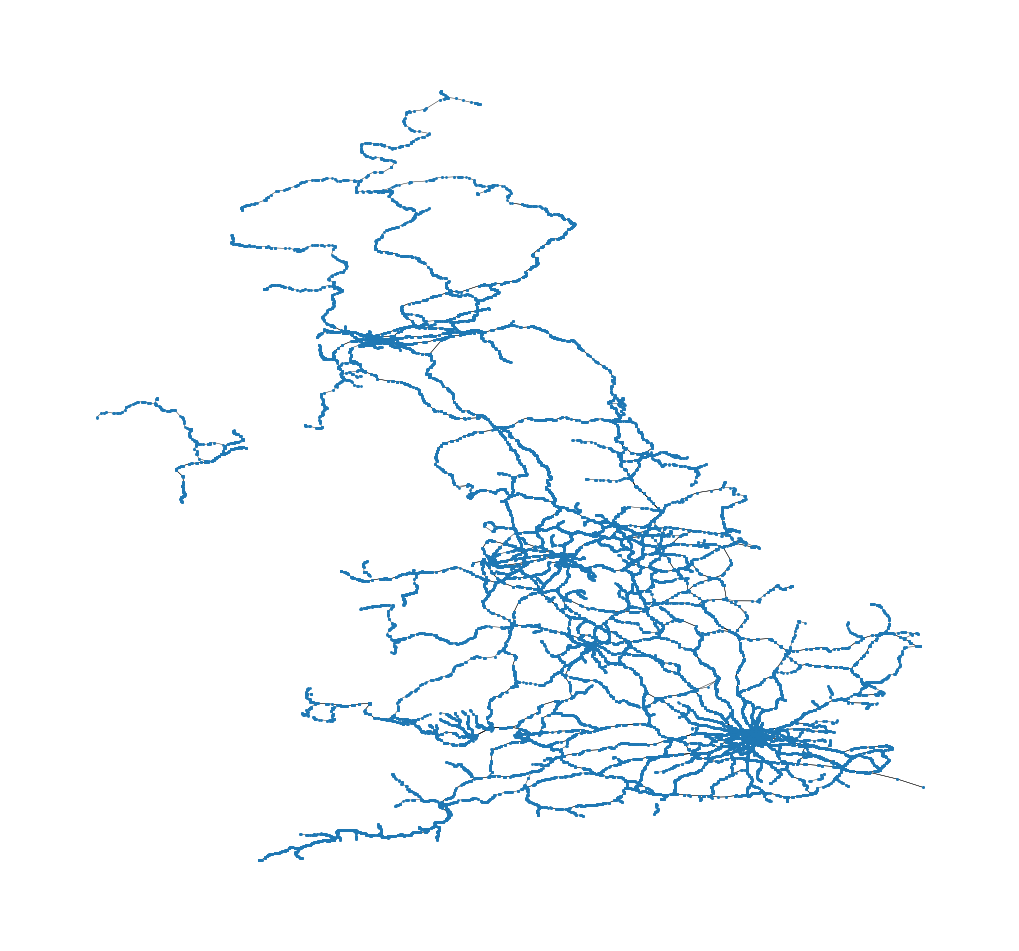

In [95]:
plt.figure(figsize=(10, 12))

pos = {n: (n[0], n[1]) for n in G_connected.nodes()}

nx.draw(
    G_connected,
    pos,
    node_size=1,
    width=0.3,
    edge_color="black"
)

plt.gca().set_aspect("equal")
plt.show()

## We want to remove Northern Ireland because it is not connected to the mainland network in real life

In [48]:
target = np.array([-5.93, 54.60]) #Longitude and latitude of Belfast (Capital of Northern Ireland)

#closest node in the graph
nodes = np.array([np.array(n) for n in G_connected.nodes()])
dists = np.linalg.norm(nodes - target, axis=1)
closest_node = tuple(nodes[dists.argmin()])

print("Closest node is :", closest_node)

#Find and remove the component associated to this point (so removing Northern Ireland)
component_NI = next(comp for comp in nx.connected_components(G_connected) if closest_node in comp)

print("NI component size :", len(component_NI))

G_final = G_connected.copy()
G_final.remove_nodes_from(component_NI)

Closest node is : (-5.9246143, 54.605539)
NI component size : 788


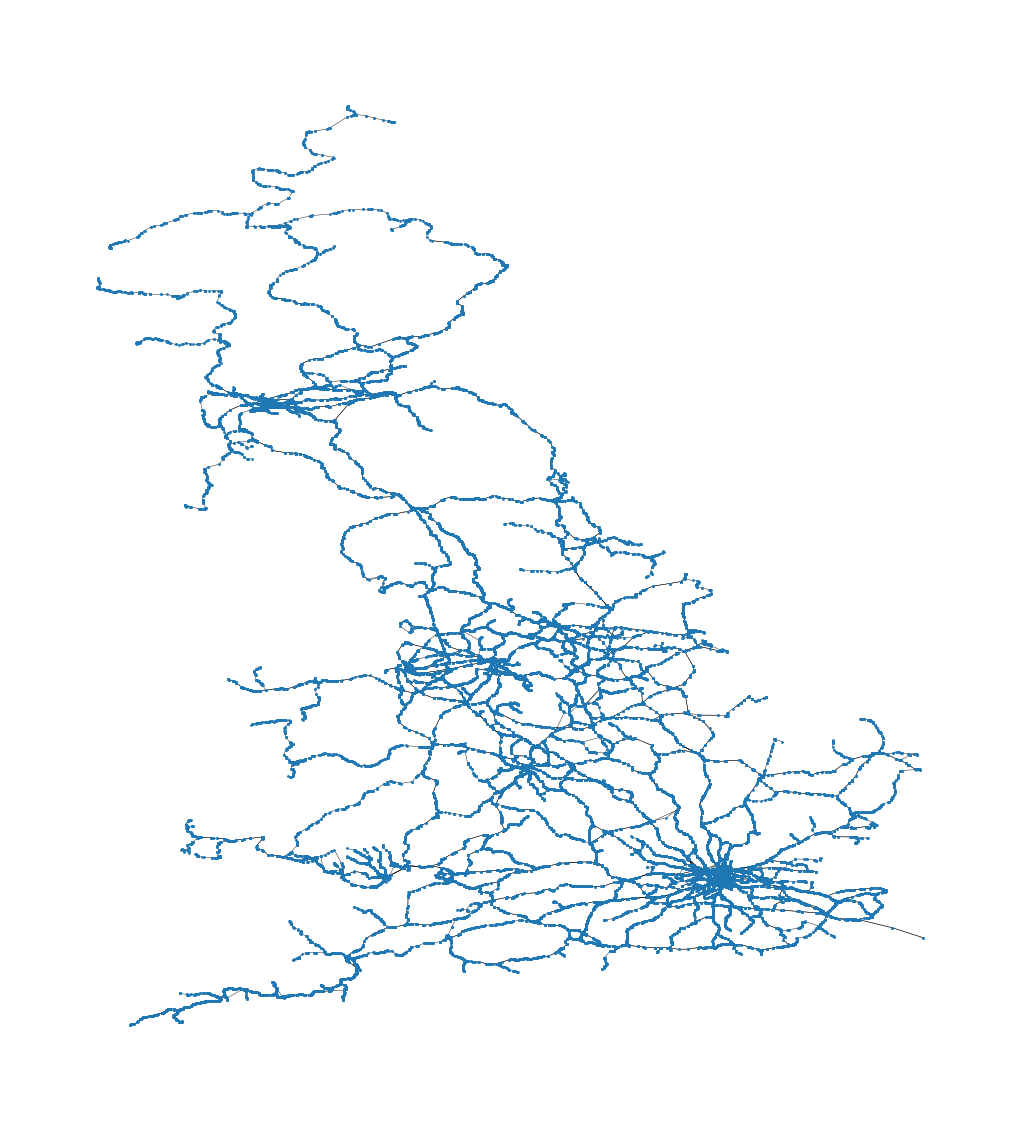

In [49]:
plt.figure(figsize=(10, 12))

pos = {n: (n[0], n[1]) for n in G_final.nodes()}
nx.draw(G_final, pos, node_size=1, width=0.3, edge_color="black")

plt.gca().set_aspect("equal")
plt.show()

In [50]:
m = folium.Map(
    location=[54, -2],
    zoom_start=6,
    tiles="CartoDB Positron"
)

#Add edges
for u, v, d in G_final.edges(data=True):
    if isinstance(u, tuple) and isinstance(v, tuple):
        folium.PolyLine(
            locations=[(u[1], u[0]), (v[1], v[0])],
            color="blue",
            weight=2,
            opacity=0.6
        ).add_to(m)

#Add nodes
for n, d in G_final.nodes(data=True):
    if not (isinstance(n, tuple) and len(n) == 2):
        continue

    lon ,lat = n

    folium.CircleMarker(
        location=[lat, lon],
        radius=1,
        color="red",
        fill=True,
        fill_opacity = 0.5
    ).add_to(m)

m.save("graph.html")
#m

### Is the network now fully connected ? Yes if there is only 1 component

In [51]:
nx.number_connected_components(G_final)

1

### Check the degrees of each node

In [52]:
degrees = [d for _, d in G_final.degree()]
print("min:", np.min(degrees))
print("max:", np.max(degrees))
print("mean:", np.mean(degrees))
print("degree=1:", degrees.count(1))
print("degree=2:", degrees.count(2))
print("degree>=3:", sum(d>=3 for d in degrees))

min: 1
max: 6
mean: 2.0546006983810257
degree=1: 2727
degree=2: 57214
degree>=3: 6212


## Add attributes

In [53]:
stations_in_G = [n for n, d in G.nodes(data=True) if d.get("type") == "station"]
len(stations_in_G)


11696

In [54]:
for n in stations_in_G:
    if n not in G_final:
        G_final.add_node(n)

for n in stations_in_G:
    G_final.nodes[n].update(G.nodes[n])

for n in stations_in_G:
    G_final.nodes[n]["stanox"] = stanox_map.get(n)


In [55]:
[(n, d) for n, d in G_final.nodes(data=True) if isinstance(n, str)][:2]

[('AACHEN',
  {'type': 'station',
   'name': 'Aachen',
   'lat': nan,
   'lon': nan,
   'crs': nan,
   'stanox': '00005'}),
 ('ABCWM',
  {'type': 'station',
   'name': 'Abercwmboi',
   'lat': nan,
   'lon': nan,
   'crs': nan,
   'stanox': '78128'})]

In [56]:
[(n, d) for n, d in G_final.nodes(data=True) if isinstance(n, tuple)][:2]

[((1.1454283, 51.2592228),
  {'type': 'osm_point', 'lon': 1.1454283, 'lat': 51.2592228}),
 ((-2.5807156, 51.4484134),
  {'type': 'osm_point', 'lon': -2.5807156, 'lat': 51.4484134})]

In [57]:
for u, v, d in G.edges(data=True):
    if u in G_final and v in G_final:
        if not G_final.has_edge(u, v):
            G_final.add_edge(u, v, **d)
        else:
            G_final[u][v].update(d)

In [58]:
list(G_final.edges(data=True))[:2]

[((1.1454283, 51.2592228),
  (1.1400766, 51.2606539),
  {'distance': 0.25163964288055435,
   'maxspeed': 90.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'FDM'}),
 ((1.1454283, 51.2592228),
  (1.1456842, 51.2591524),
  {'distance': 0.012086838315614417,
   'maxspeed': 90.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'FDM'})]

In [96]:
G_final.number_of_nodes(), G_final.number_of_edges()

(77849, 79227)

## Save graph

In [59]:
#Optionnal
with open("graph.gpickle", "wb") as f:
    pickle.dump(G_final, f)

## Load graph

In [60]:
#Optionnal
with open("graph.gpickle", "rb") as f:
    G_final = pickle.load(f)

====================================================================================
=============================TEST===================================================
====================================================================================

## Area to be tested 

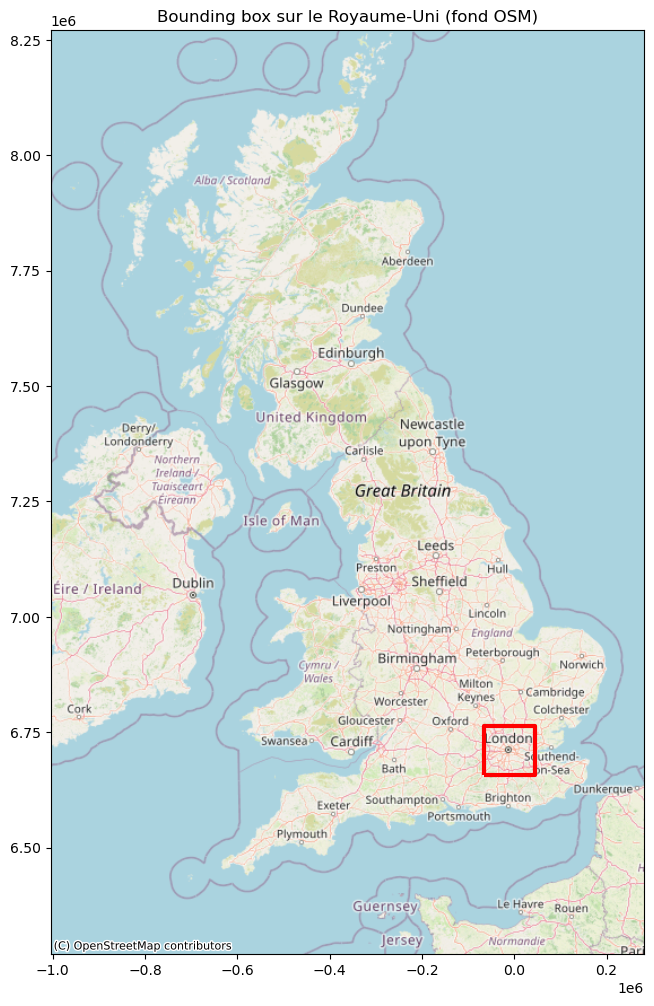

In [99]:

#Bounding box to test (can be modified)
minx, miny = -0.6, 51.2
maxx, maxy = 0.4, 51.8

bbox_poly = box(minx, miny, maxx, maxy)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326")

uk_minx, uk_miny = -8.5, 49.5
uk_maxx, uk_maxy = 2.0, 59.0

uk_poly = box(uk_minx, uk_miny, uk_maxx, uk_maxy)
uk_gdf = gpd.GeoDataFrame(geometry=[uk_poly], crs="EPSG:4326")

uk_web = uk_gdf.to_crs(3857)
bbox_web = bbox_gdf.to_crs(3857)

# --- 4) Affichage ---
fig, ax = plt.subplots(figsize=(10, 12))

# UK rectangle (juste pour cadrer la carte)
uk_web.boundary.plot(ax=ax, linewidth=0)

# bounding box rouge
bbox_web.boundary.plot(ax=ax, color="red", linewidth=3)

# fond de carte OSM
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Bounding box sur le Royaume-Uni (fond OSM)")
plt.show()


## Subgraph

In [62]:
lat_min, lat_max = 51.2, 51.8
lon_min, lon_max = -0.6, 0.4

nodes_to_keep = []

for n, d in G.nodes(data=True):

    lat = d.get("lat")
    lon = d.get("lon")

    if lat is not None and lon is not None:

        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            nodes_to_keep.append(n)

G_london = G.subgraph(nodes_to_keep).copy()

In [63]:
largest_cc = max(nx.connected_components(G_london), key=len)

G_london = G_london.subgraph(largest_cc).copy()

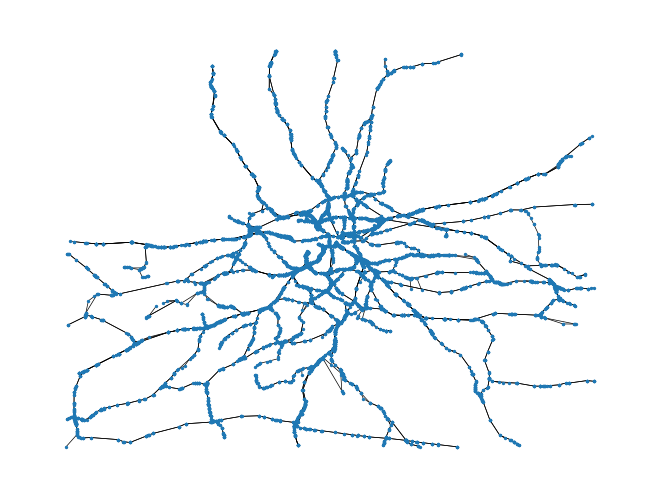

In [64]:
pos = {
    n: (d["lon"], d["lat"])
    for n, d in G_london.nodes(data=True)
    if "lon" in d and "lat" in d
}

nx.draw(
    G_london,
    pos,
    node_size=2,
    width=0.5,
    with_labels=False
)

In [65]:
print("Nodes :", G_london.number_of_nodes())
print("Edges :", G_london.number_of_edges())

Nodes : 10095
Edges : 10454


In [66]:
print(nx.number_connected_components(G_london))

1


In [67]:
degrees = [d for n, d in G_london.degree()]

avg_degree = sum(degrees) / len(degrees)

print(avg_degree)

2.071124318969787


In [68]:
list(G_final.nodes(data=True))[:2]

[((1.1454283, 51.2592228),
  {'type': 'osm_point', 'lon': 1.1454283, 'lat': 51.2592228}),
 ((-2.5807156, 51.4484134),
  {'type': 'osm_point', 'lon': -2.5807156, 'lat': 51.4484134})]

In [69]:
list(G_london.edges(data=True))[:2]

[((-0.0988616, 51.4973916),
  (-0.0985157, 51.4951534),
  {'distance': 0.15536053947488085,
   'maxspeed': 60.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'HHH'}),
 ((-0.0988616, 51.4973916),
  (-0.099215, 51.4980146),
  {'distance': 0.04565088254080461,
   'maxspeed': 60.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 4,
   'usage': 'main',
   'elr': nan})]

# Add name and tiploc

In [70]:
valid_nodes = []
valid_coords = []

for n in G_london.nodes:
    if n in G.nodes:
        d = G.nodes[n]
        lon = d.get("lon")
        lat = d.get("lat")

        # garder uniquement les coordonnées finies
        if lon is not None and lat is not None and math.isfinite(lon) and math.isfinite(lat):
            valid_nodes.append(n)
            valid_coords.append([lon, lat])

valid_coords = np.array(valid_coords)
tree = cKDTree(valid_coords)

for _, row in df_name_loc.iterrows():
    lon = row["long"]
    lat = row["lat"]

    # ignorer les lignes invalides
    if lon is None or lat is None:
        continue
    if not (math.isfinite(lon) and math.isfinite(lat)):
        continue

    tiploc = row["tiploc"]
    name = row["name"]

    # nearest neighbour dans les nœuds valides
    dist, idx = tree.query([lon, lat])
    nearest_node = valid_nodes[idx]

    # ajouter les attributs dans G_london
    G_london.nodes[nearest_node]["tiploc"] = tiploc
    G_london.nodes[nearest_node]["name"] = name


In [71]:
count_tiploc = sum(
    1 for n, d in G_london.nodes(data=True)
    if "tiploc" in d
)

count_name = sum(
    1 for n, d in G_london.nodes(data=True)
    if "name" in d
)

print("Nœuds avec tiploc :", count_tiploc)
print("Nœuds avec name   :", count_name)
print("Total nœuds       :", G_london.number_of_nodes())


Nœuds avec tiploc : 460
Nœuds avec name   : 463
Total nœuds       : 10095


## Add stanox

In [72]:
df_STAN_TIP.columns

Index(['id', 'NLC', 'STANOX', 'TIPLOC', '3ALPHA', 'UIC', 'NLCDESC',
       'NLCDESC16'],
      dtype='object')

In [73]:
tiploc_to_stanox = {
    row["TIPLOC"]: row["STANOX"]
    for _, row in df_STAN_TIP.iterrows()
    if isinstance(row["TIPLOC"], str)
}

count_added = 0

for n, d in G_london.nodes(data=True):
    tiploc = d.get("tiploc")
    if tiploc in tiploc_to_stanox:
        G_london.nodes[n]["stanox"] = tiploc_to_stanox[tiploc]
        count_added += 1

print("STANOX added :", count_added)


STANOX added : 457


In [74]:
count_stanox = sum(
    1 for _, d in G_london.nodes(data=True)
    if "stanox" in d
)

print("Nœuds avec stanox :", count_stanox)
print("Nœuds avec tiploc :", sum("tiploc" in d for _, d in G_london.nodes(data=True)))


Nœuds avec stanox : 462
Nœuds avec tiploc : 460


In [75]:
sample = [
    (n, {k: d[k] for k in ["lon", "lat", "tiploc", "name", "stanox"] if k in d})
    for n, d in G_london.nodes(data=True)
    if "tiploc" in d
][:10]

sample


[('TULSEH',
  {'lon': -0.10506,
   'lat': 51.439713,
   'tiploc': 'TULSEH',
   'name': 'Tulse Hill',
   'stanox': '87611'}),
 ('SHRTLND',
  {'lon': 0.002798,
   'lat': 51.405548,
   'tiploc': 'SHRTLND',
   'name': 'Shortlands',
   'stanox': '88474'}),
 ('HERNEH',
  {'lon': -0.101624,
   'lat': 51.453148,
   'tiploc': 'HERNEH',
   'name': 'Herne Hill',
   'stanox': '87249'}),
 ('SIDCUP',
  {'lon': 0.103342,
   'lat': 51.434361,
   'tiploc': 'SIDCUP',
   'name': 'Sidcup',
   'stanox': '88461'}),
 ('PURFLET',
  {'lon': 0.236575,
   'lat': 51.481358,
   'tiploc': 'PURFLET',
   'name': 'Purfleet',
   'stanox': '51344'}),
 ((0.1197351, 51.5667313),
  {'lon': 0.1197351,
   'lat': 51.5667313,
   'tiploc': 'GODMAYS',
   'name': 'Goodmayes',
   'stanox': '50412'}),
 ('BRIXTON',
  {'lon': -0.114164,
   'lat': 51.463245,
   'tiploc': 'BRIXTON',
   'name': 'Brixton',
   'stanox': '87248'}),
 ('EDNB',
  {'lon': 0.060099,
   'lat': 51.208508,
   'tiploc': 'EDNB',
   'name': 'Edenbridge',
   'stanox':

# Try a simpler graph

In [140]:
G_simple = G_london.copy()

changed = True

while changed:

    changed = False

    nodes_to_remove = []

    for n, data in list(G_simple.nodes(data=True)):

        # -------------------------------------------------
        # Keep stations / operational nodes
        # -------------------------------------------------

        if data.get("type") == "station":
            continue

        # -------------------------------------------------
        # Simplify only degree-2 osm points
        # -------------------------------------------------

        if (
            data.get("type") == "osm_point"
            and G_simple.degree(n) == 2
        ):

            neighbors = list(G_simple.neighbors(n))

            if len(neighbors) != 2:
                continue

            u, v = neighbors

            # avoid self-loop
            if u == v:
                continue

            # -------------------------------------------------
            # Get edge attributes
            # -------------------------------------------------

            edge1 = G_simple.get_edge_data(u, n)
            edge2 = G_simple.get_edge_data(n, v)

            # -------------------------------------------------
            # Merge attributes
            # -------------------------------------------------

            new_attrs = {}

            # distance
            dist1 = edge1.get("distance", 0)
            dist2 = edge2.get("distance", 0)

            new_attrs["distance"] = dist1 + dist2

            # travel time
            tt1 = edge1.get("min_travel_time", 0)
            tt2 = edge2.get("min_travel_time", 0)

            new_attrs["min_travel_time"] = tt1 + tt2

            # keep restrictive / representative attributes

            g1 = edge1.get("loading_gauge")
            g2 = edge2.get("loading_gauge")

            # default if missing
            if g1 is None or str(g1) == "nan":
                g1 = "W6"

            if g2 is None or str(g2) == "nan":
                g2 = "W6"

            # ordered gauges
            gauge_order = {
                "W6": 1,
                "W7": 2,
                "W8": 3,
                "W9": 4,
                "W10": 5,
                "W12": 6
            }

            # keep most restrictive
            if gauge_order.get(g1, 1) <= gauge_order.get(g2, 1):
                new_attrs["loading_gauge"] = g1
            else:
                new_attrs["loading_gauge"] = g2

            new_attrs["tracks"] = min(
                int(edge1.get("tracks", 1)),
                int(edge2.get("tracks", 1))
            )

            # electrification
            elec1 = edge1.get("electrified")
            elec2 = edge2.get("electrified")

            if elec1 == elec2:
                new_attrs["electrified"] = elec1
            else:
                new_attrs["electrified"] = "mixed"

            # usage
            usage1 = edge1.get("usage")
            usage2 = edge2.get("usage")

            if usage1 == usage2:
                new_attrs["usage"] = usage1
            else:
                new_attrs["usage"] = "mixed"

            # gauge
            gauge1 = edge1.get("gauge")
            gauge2 = edge2.get("gauge")

            if gauge1 == gauge2:
                new_attrs["gauge"] = gauge1
            else:
                new_attrs["gauge"] = "mixed"

            # keep ELR if possible
            elr1 = edge1.get("elr")
            elr2 = edge2.get("elr")

            if elr1 == elr2:
                new_attrs["elr"] = elr1

            # -------------------------------------------------
            # Add merged edge
            # -------------------------------------------------

            if not G_simple.has_edge(u, v):

                G_simple.add_edge(u, v, **new_attrs)

            else:

                # if edge already exists,
                # keep shortest distance

                existing = G_simple[u][v]

                if new_attrs["distance"] < existing.get("distance", 999999):

                    G_simple[u][v].update(new_attrs)

            # -------------------------------------------------
            # Remove intermediate node
            # -------------------------------------------------

            nodes_to_remove.append(n)

            changed = True

    G_simple.remove_nodes_from(nodes_to_remove)

# =========================================================
# RESULTS
# =========================================================

print("Original graph")
print("Nodes:", G_london.number_of_nodes())
print("Edges:", G_london.number_of_edges())

print("\nSimplified graph")
print("Nodes:", G_simple.number_of_nodes())
print("Edges:", G_simple.number_of_edges())

Original graph
Nodes: 10095
Edges: 10454

Simplified graph
Nodes: 2258
Edges: 2607


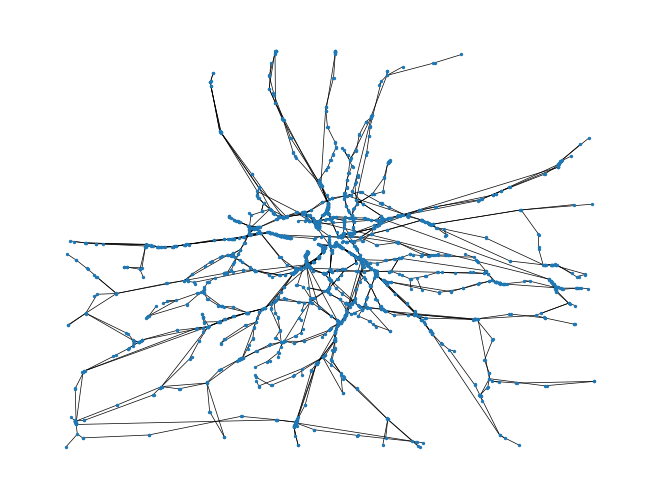

In [141]:
pos = {
    n: (d["lon"], d["lat"])
    for n, d in G_simple.nodes(data=True)
    if "lon" in d and "lat" in d
}

nx.draw(
    G_simple,
    pos,
    node_size=2,
    width=0.5,
    with_labels=False
)

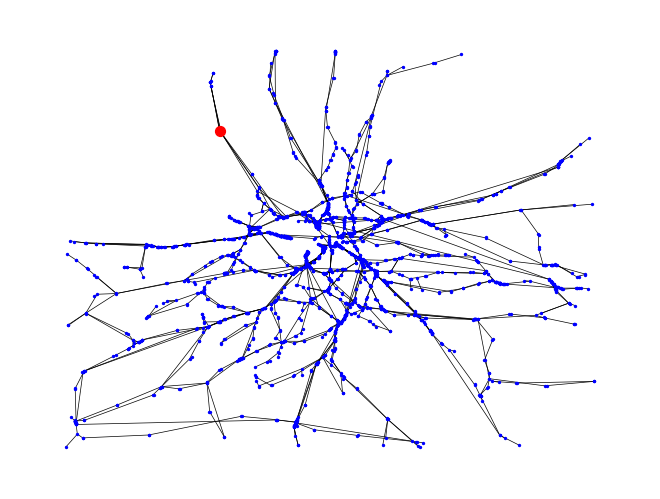

In [149]:
import networkx as nx
import matplotlib.pyplot as plt

pos = {
    n: (d["lon"], d["lat"])
    for n, d in G_simple.nodes(data=True)
    if "lon" in d and "lat" in d
}

# Dessin du graphe complet
nx.draw(
    G_simple,
    pos,
    node_size=2,
    width=0.5,
    with_labels=False,
    node_color="blue"
)

# Recherche du node "Radlett"
radlett_nodes = [
    n for n, d in G_simple.nodes(data=True)
    if d.get("name") == "Radlett"
]

# Dessin en rouge
nx.draw_networkx_nodes(
    G_simple,
    pos,
    nodelist=radlett_nodes,
    node_color="red",
    node_size=50
)

plt.show()

In [144]:
top_degree = sorted(
    G_simple.degree(),
    key=lambda x: x[1],
    reverse=True
)[:20]

for node, degree in top_degree:
    attrs = G_simple.nodes[node]

    if "name" in attrs:
        display_name = attrs["name"]
    elif "tiploc" in attrs:
        display_name = attrs["tiploc"]
    else:
        display_name = "Unknown"

    print(f"{display_name} ({node}) : {degree}")

Unknown ((-0.0863657, 51.3861687)) : 4
Unknown ((-0.1149192, 51.4995671)) : 4
Unknown ((-0.0613572, 51.550288)) : 4
Unknown ((-0.0145929, 51.4659457)) : 4
Unknown ((-0.0596597, 51.5470377)) : 4
Unknown ((0.0042518, 51.446856)) : 4
Unknown ((-0.1150438, 51.4971623)) : 4
Unknown ((0.0251778, 51.5098454)) : 4
Unknown ((-0.1149285, 51.4974397)) : 4
Unknown ((-0.4192922, 51.2918841)) : 4
Unknown ((-0.0054259, 51.5408142)) : 4
Unknown ((-0.1149876, 51.4971341)) : 4
Unknown ((-0.5619278, 51.4028783)) : 4
Unknown ((-0.1151909, 51.4969294)) : 4
Unknown ((-0.2554898, 51.5218732)) : 4
Unknown ((-0.1145392, 51.5005458)) : 4
Unknown ((-0.0807342, 51.5204417)) : 4
Unknown ((-0.243849, 51.5310575)) : 4
Unknown ((-0.1148597, 51.4995452)) : 4
Unknown ((-0.1152346, 51.4995132)) : 4


In [145]:
station_nodes = [
    (node, degree)
    for node, degree in G_simple.degree()
    if "name" in G_simple.nodes[node]
]

top_degree = sorted(
    station_nodes,
    key=lambda x: x[1],
    reverse=True
)[:20]

for node, degree in top_degree:
    print(G_simple.nodes[node]["name"], degree)

Hatch End 3
Upminster 3
Gerrards Cross 3
West Ruislip 3
Staines 3
Barnes 3
South Acton 3
Southall 3
Twickenham 3
Wembley Stadium 3
South Ruislip 3
Radlett 3
Battersea Park 3
Slade Green 3
Tulse Hill 1
Shortlands 1
Herne Hill 1
Sidcup 1
Purfleet 1
Brixton 1


In [148]:
print("Number of components:", nx.number_connected_components(G_simple))

Number of components: 1


In [ ]:
def clean_redundant_edges(G):
    # On crée une copie pour ne pas modifier l'original pendant l'itération
    H = G.copy()
    
    # On cherche les paires de nœuds qui ont plus d'un lien entre eux
    for u, v in G.edges():
        # Si c'est un MultiGraph, on réduit à une seule arête
        # Si c'est un Graph simple, NetworkX le fait déjà, 
        # mais vérifions si tu as des nœuds très proches qui devraient être fusionnés.
        pass

    # Approche radicale : On garde l'arête la plus courte entre deux points
    G_final = nx.Graph()
    for u, v, data in G.edges(data=True):
        if G_final.has_edge(u, v):
            # Si l'arête existe déjà, on ne garde que la plus courte (la plus "legit")
            if data.get('length', 999) < G_final[u][v]['length']:
                G_final[u][v].update(data)
        else:
            G_final.add_edge(u, v, **data)
    return G_final

G_london_clean = clean_redundant_edges(G_london)

## Analysis of the subgraph (London)

In [76]:
print("Nodes:", G_london.number_of_nodes())
print("Edges:", G_london.number_of_edges())
print("Number of components:", nx.number_connected_components(G_london))

Nodes: 10095
Edges: 10454
Number of components: 1


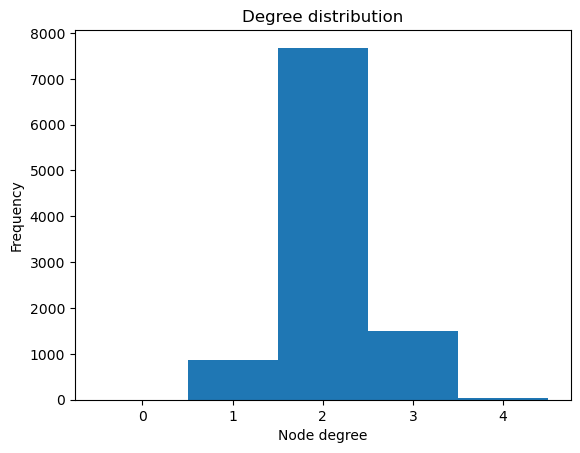

In [77]:
degrees = [d for n, d in G_london.degree()]

plt.hist(degrees, bins=range(max(degrees)+2), align='left')

plt.xlabel("Node degree")
plt.ylabel("Frequency")
plt.title("Degree distribution")

plt.show()

In [136]:
top_degree = sorted(
    G_london.degree(),
    key=lambda x: x[1],
    reverse=True
)[:20]

for node, degree in top_degree:
    attrs = G_london.nodes[node]

    if "name" in attrs:
        display_name = attrs["name"]
    elif "tiploc" in attrs:
        display_name = attrs["tiploc"]
    else:
        display_name = "Unknown"

    print(f"{display_name} ({node}) : {degree}")

Unknown ((-0.0863657, 51.3861687)) : 4
Unknown ((-0.1149192, 51.4995671)) : 4
Unknown ((-0.0873369, 51.5200807)) : 4
Unknown ((-0.0613572, 51.550288)) : 4
Unknown ((-0.0145929, 51.4659457)) : 4
Unknown ((-0.0596597, 51.5470377)) : 4
Unknown ((0.0042518, 51.446856)) : 4
Unknown ((-0.1150438, 51.4971623)) : 4
Unknown ((0.0251778, 51.5098454)) : 4
Unknown ((-0.1149285, 51.4974397)) : 4
Unknown ((-0.4192922, 51.2918841)) : 4
Unknown ((-0.0054259, 51.5408142)) : 4
Unknown ((-0.1149876, 51.4971341)) : 4
Unknown ((-0.5619278, 51.4028783)) : 4
Unknown ((-0.1151909, 51.4969294)) : 4
Unknown ((-0.2554898, 51.5218732)) : 4
Unknown ((-0.1145392, 51.5005458)) : 4
Unknown ((-0.0807342, 51.5204417)) : 4
Unknown ((-0.243849, 51.5310575)) : 4
Unknown ((-0.1148597, 51.4995452)) : 4


In [151]:
station_nodes = [
    (node, degree)
    for node, degree in G_london.degree()
    if "name" in G_london.nodes[node]
]

top_degree = sorted(
    station_nodes,
    key=lambda x: x[1],
    reverse=True
)

for node, degree in top_degree:
    print(G_london.nodes[node]["name"], degree)

Hatch End 3
Upminster 3
Gerrards Cross 3
West Ruislip 3
Staines 3
Barnes 3
South Acton 3
Southall 3
Twickenham 3
Wembley Stadium 3
South Ruislip 3
Harringay 3
Radlett 3
Battersea Park 3
Slade Green 3
Goodmayes 2
West Drayton 2
Iver 2
London Marylebone 2
Emerson Park 2
Watford North 2
Oxted 2
South Hampstead 2
Wokingham 2
Kensal Rise 2
Harlow Mill 2
Tolworth 2
Hever 2
Bricket Wood 2
Broxbourne 2
Upper Holloway 2
Watford Junction 2
Streatham Hill 2
Hanwell 2
Enfield Town 2
Park Street 2
Dorking 2
Greenford 2
Rickmansworth 2
Sydenham 2
Angmering 2
London Euston 2
Northolt Park 2
Brookwood 2
Chadwell Heath 2
Hornsey 2
Surbiton 2
Earlswood (Surrey) 2
West Horndon 2
Hemel Hempstead 2
Grove Park 2
Alexandra Palace 2
Sundridge Park 2
Norwood Junction 2
How Wood 2
Woking 2
Chilworth 2
Harlesden 2
Brimsdown 2
Leigh (Kent) 2
St Helier 2
Clapham Junction 2
New Southgate 2
Chertsey 2
Bellingham 2
Dorking West 2
Stonebridge Park 2
Stratford International 2
Pulborough 2
Whitby 2
Acton Main Line 2
Den

In [80]:
bc = nx.betweenness_centrality(
    G_london,
    normalized=True
)

In [83]:
top_bc = sorted(
    bc.items(),
    key=lambda x: x[1],
    reverse=True
)

for node, value in top_bc:
    attrs = G_london.nodes[node]

    display_name = display_name = (attrs.get("name") or attrs.get("tiploc") or "Unknown")

    print(f"{display_name} ({node}) : {value}")

Unknown ((-0.1025663, 51.5050675)) : 0.2104177131959993
Unknown ((-0.1281271, 51.5336493)) : 0.20709712664197963
Unknown ((-0.2554898, 51.5218732)) : 0.19294749306940118
Unknown ((-0.1032867, 51.5084005)) : 0.1881887558909218
Unknown ((-0.1032473, 51.5111287)) : 0.18809960742721835
Unknown ((-0.1033196, 51.5115055)) : 0.1880111715753766
Unknown ((-0.1033934, 51.5118006)) : 0.18792342543235238
Unknown ((-0.1034253, 51.5119248)) : 0.18783641873047013
Unknown ((-0.1034745, 51.5121487)) : 0.1877506095306144
Unknown ((-0.1035662, 51.5129841)) : 0.18766701211045783
Unknown ((-0.1035633, 51.5141218)) : 0.18758516840911596
Unknown ((-0.1039205, 51.517687)) : 0.18750380239983933
Unknown ((-0.1044206, 51.5194725)) : 0.18743577250602692
Unknown ((-0.1044511, 51.5195404)) : 0.18738099365922886
Unknown ((-0.1047485, 51.5199553)) : 0.18732672522313057
Unknown ((-0.1047818, 51.5199882)) : 0.18727311246846975
Unknown ((-0.1050599, 51.5202707)) : 0.18721992767354959
Unknown ((-0.1063083, 51.5218148)) :

In [84]:
gauges = []

for u, v, d in G_london.edges(data=True):
    gauges.append(d.get("loading_gauge"))

gauges_counts = pd.Series(gauges).value_counts(dropna=False)
print(gauges_counts)

7.0     5905
10.0    3576
6.0      487
NaN      343
8.0      132
9.0       11
Name: count, dtype: int64


In [85]:
electrification = []

for u, v, d in G_london.edges(data=True):
    electrification.append(d.get("electrified"))

elec_counts = pd.Series(electrification).value_counts(dropna=False)
print(elec_counts)

3rd_Rail    5895
Overhead    3864
No           352
None         343
Name: count, dtype: int64


## Save subgraph

In [86]:
#Optionnal
with open("subgraph.gpickle", "wb") as f:
    pickle.dump(G_london, f)

## Load subgraph

In [ ]:
#Optionnal
with open("subgraph.gpickle", "rb") as f:
    G_london = pickle.load(f)

## Network resilience

In [ ]:
closeness_globale = nx.closeness_centrality(G_london, distance='length')
nx.set_node_attributes(G_london, closeness_globale, 'closeness')
top_5_topo = sorted(closeness_globale.items(), key=lambda x: x[1], reverse=True)[:100]

In [170]:
top_5_topo = sorted(closeness_globale.items(), key=lambda x: x[1], reverse=True)[:20]

In [169]:
print("\n--- LE VRAI TOP 5 DES HUBS STRUCTURELS ---")
for i, (node, score) in enumerate(top_5_topo, 1):
    node_data = G_london.nodes[node]
    
    # On récupère les coordonnées directement depuis le tuple (node)
    lon, lat = node[0], node[1]
    
    # On cherche s'il y a un ID technique (TIPLOC ou STANOX) pour pouvoir l'identifier
    tiploc = node_data.get('tiploc', 'Unknown')
    stanox = node_data.get('stanox', 'Unknown')
    nom = node_data.get('name')
    
    if nom:
        print(f"Top {i}: Gare: {nom} (STANOX: {stanox}) | Score: {score:.5f}")
    else:
        # Si c'est une jonction anonyme, on donne les clés pour l'identifier
        print(f"Top {i}: Unknown junction (TIPLOC: {tiploc} | STANOX: {stanox})", "Coordinates : ", (lat, lon), f"Score: {score:.5f}")


--- LE VRAI TOP 5 DES HUBS STRUCTURELS ---
Top 1: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.469214, -0.1019655) Score: 0.01149
Top 2: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4688812, -0.102015) Score: 0.01148
Top 3: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4680616, -0.1022069) Score: 0.01147
Top 4: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4931499, -0.09897) Score: 0.01145
Top 5: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4678385, -0.1022275) Score: 0.01145
Top 6: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4692252, -0.1019618) Score: 0.01144
Top 7: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4951428, -0.0983892) Score: 0.01143
Top 8: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4987277, -0.0996115) Score: 0.01142
Top 9: Unknown junction (TIPLOC: Unknown

In [174]:
def simuler_courbes_resilience(G, proportions_retrait=0.15, pas=5):
    """
    G: Ton G_principal
    proportions_retrait: Le % maximum de nœuds qu'on va supprimer (15% c'est déjà énorme)
    pas: On supprime 'pas' nœuds à chaque étape pour que le calcul soit rapide
    """
    N_total = len(G.nodes())
    nb_noeuds_a_retirer = int(N_total * proportions_retrait)
    
    # --- 1. PRÉPARATION DES SÉQUENCES D'ATTAQUE ---
    # Attaque ciblée : On trie les nœuds du plus central au moins central
    closeness_dict = nx.closeness_centrality(G, distance='length')
    noeuds_cibles = [n for n, score in sorted(closeness_dict.items(), key=lambda x: x[1], reverse=True)]
    
    # Attaque aléatoire : On mélange la liste des nœuds au hasard
    noeuds_aleatoires = list(G.nodes())
    random.shuffle(noeuds_aleatoires)
    
    # --- 2. SIMULATION ---
    courbe_random = [1.0] # 100% du réseau connecté au départ
    courbe_targeted = [1.0]
    X_axes = [0]
    
    # Simulation Aléatoire
    G_rand = G.copy()
    for i in range(0, nb_noeuds_a_retirer, pas):
        noeuds_suppr = noeuds_aleatoires[i : i + pas]
        G_rand.remove_nodes_from(noeuds_suppr)
        if len(G_rand) > 0:
            lcc_size = len(max(nx.connected_components(G_rand), key=len)) / N_total
            courbe_random.append(lcc_size)
        else:
            courbe_random.append(0)
            
    # Simulation Ciblée (Closeness)
    G_target = G.copy()
    for i in range(0, nb_noeuds_a_retirer, pas):
        noeuds_suppr = noeuds_cibles[i : i + pas]
        G_target.remove_nodes_from(noeuds_suppr)
        if len(G_target) > 0:
            lcc_size = len(max(nx.connected_components(G_target), key=len)) / N_total
            courbe_targeted.append(lcc_size)
        else:
            courbe_targeted.append(0)
            
        X_axes.append(i + pas)
        # Regarde ce que donne le nombre de composantes à la fin de tes boucles dans ton code actuel :
        # (Tu peux rajouter cette métrique dans ta fonction de simulation)
        nb_composantes_random = len(list(nx.connected_components(G_rand)))
        nb_composantes_targeted = len(list(nx.connected_components(G_target)))

        print(f"Nombre de morceaux isolés créés par le Random : {nb_composantes_random}")
        print(f"Nombre de morceaux isolés créés par la Closeness : {nb_composantes_targeted}")
                
    return X_axes, courbe_random, courbe_targeted


X, y_random, y_targeted = simuler_courbes_resilience(G_london, proportions_retrait=0.10, pas=2)

Nombre de morceaux isolés créés par le Random : 691
Nombre de morceaux isolés créés par la Closeness : 1
Nombre de morceaux isolés créés par le Random : 691
Nombre de morceaux isolés créés par la Closeness : 1
Nombre de morceaux isolés créés par le Random : 691
Nombre de morceaux isolés créés par la Closeness : 1
Nombre de morceaux isolés créés par le Random : 691
Nombre de morceaux isolés créés par la Closeness : 1
Nombre de morceaux isolés créés par le Random : 691
Nombre de morceaux isolés créés par la Closeness : 2
Nombre de morceaux isolés créés par le Random : 691
Nombre de morceaux isolés créés par la Closeness : 2
Nombre de morceaux isolés créés par le Random : 691
Nombre de morceaux isolés créés par la Closeness : 2
Nombre de morceaux isolés créés par le Random : 691
Nombre de morceaux isolés créés par la Closeness : 3
Nombre de morceaux isolés créés par le Random : 691
Nombre de morceaux isolés créés par la Closeness : 3
Nombre de morceaux isolés créés par le Random : 691
Nom

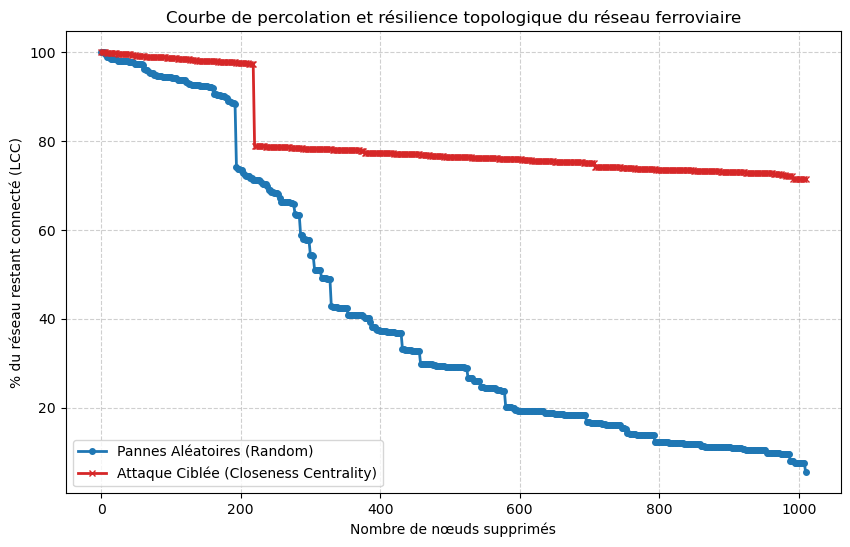

In [175]:
plt.figure(figsize=(10, 6))

plt.plot(X, [y * 100 for y in y_random], label='Pannes Aléatoires (Random)', color='tab:blue', linewidth=2, marker='o', markersize=4)
plt.plot(X, [y * 100 for y in y_targeted], label='Attaque Ciblée (Closeness Centrality)', color='tab:red', linewidth=2, marker='x', markersize=4)

plt.title("Courbe de percolation et résilience topologique du réseau ferroviaire")
plt.xlabel("Nombre de nœuds supprimés")
plt.ylabel("% du réseau restant connecté (LCC)")
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Nombre total de nœuds dans le réseau principal : 10095
La simulation va retirer jusqu'à 5047 nœuds (par pas de 252)


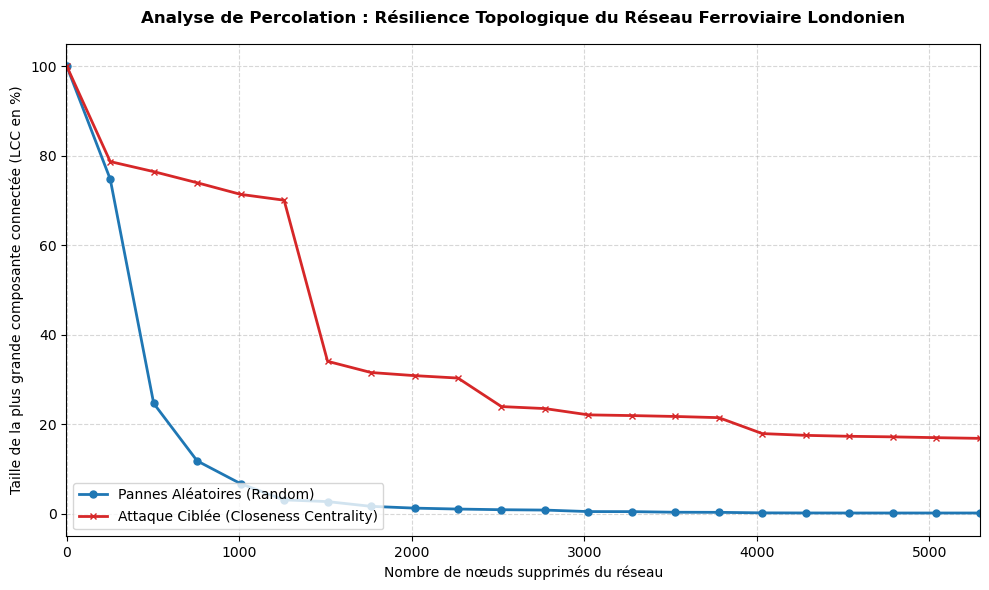

In [183]:
def simuler_resilience_finale(G, max_retrait=120, pas=5):
    N_total = len(G.nodes())
    
    # 1. Calcul de la Closeness pour l'attaque ciblée
    closeness_dict = nx.closeness_centrality(G, distance='length')
    noeuds_cibles = [n for n, score in sorted(closeness_dict.items(), key=lambda x: x[1], reverse=True)]
    
    # 2. Mélange aléatoire pour les pannes
    noeuds_aleatoires = list(G.nodes())
    random.shuffle(noeuds_aleatoires)
    
    # Listes pour stocker la taille de la plus grande composante (%)
    lcc_random = [100.0]
    lcc_targeted = [100.0]
    X_noeuds = [0]
    
    # Simulation Aléatoire (Random)
    G_rand = G.copy()
    for i in range(0, max_retrait, pas):
        noeuds_a_retirer = noeuds_aleatoires[i:i+pas]
        G_rand.remove_nodes_from(noeuds_a_retirer)
        if len(G_rand) > 0:
            taille_lcc = len(max(nx.connected_components(G_rand), key=len)) / N_total * 100
            lcc_random.append(taille_lcc)
        else:
            lcc_random.append(0)
            
    # Simulation Ciblée (Closeness)
    G_target = G.copy()
    for i in range(0, max_retrait, pas):
        noeuds_a_retirer = noeuds_cibles[i:i+pas]
        G_target.remove_nodes_from(noeuds_a_retirer)
        if len(G_target) > 0:
            taille_lcc = len(max(nx.connected_components(G_target), key=len)) / N_total * 100
            lcc_targeted.append(taille_lcc)
        else:
            lcc_targeted.append(0)
            
        X_noeuds.append(i + pas)
        
    return X_noeuds, lcc_random, lcc_targeted

# 1. On lance la simulation sur ton G_principal
# 1. On regarde combien de nœuds on a au total
N_total = len(G_london.nodes())
print(f"Nombre total de nœuds dans le réseau principal : {N_total}")

# 2. On décide de pousser l'attaque jusqu'à 50% du réseau total
# On augmente le 'pas' à 15 ou 20 pour que le calcul ne prenne pas 3 heures
max_noeuds_a_retirer = int(N_total * 0.50)
pas_voulise = int(max_noeuds_a_retirer / 20) # Pour avoir environ 20 points sur le graphique

print(f"La simulation va retirer jusqu'à {max_noeuds_a_retirer} nœuds (par pas de {pas_voulise})")

# 3. On relance la fonction avec ces vraies proportions
X, y_rand, y_target = simuler_resilience_finale(G_london, max_retrait=max_noeuds_a_retirer, pas=pas_voulise)

# 2. On trace le graphique propre pour le mémoire
plt.figure(figsize=(10, 6))

plt.plot(X, y_rand, label='Pannes Aléatoires (Random)', color='tab:blue', linewidth=2, marker='o', markersize=5)
plt.plot(X, y_target, label='Attaque Ciblée (Closeness Centrality)', color='tab:red', linewidth=2, marker='x', markersize=5)

plt.title("Analyse de Percolation : Résilience Topologique du Réseau Ferroviaire Londonien", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Nombre de nœuds supprimés du réseau", fontsize=10)
plt.ylabel("Taille de la plus grande composante connectée (LCC en %)", fontsize=10)
plt.ylim(-5, 105)
plt.xlim(-2, max(X) + 2)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Test with gcc

In [119]:
def measure_gcc(G, initial_size=None):
    """Calculates relative size of Giant Connected Component."""
    if len(G) == 0:
        return 0
    connected_components = list(nx.connected_components(G))
    if not connected_components:
        return 0
    largest_cc = max(connected_components, key=len)
    if initial_size is not None:
        return len(largest_cc) / initial_size
    else:
        return len(largest_cc) / len(G)

In [121]:
import random
G_london_damaged = G_london.copy()
initial_size = G_london.number_of_nodes()

bet = nx.betweenness_centrality(G_london_damaged, k=100, seed=42)

target_nodes = sorted(
    bet,
    key=bet.get,
    reverse=True
)

random_nodes = list(G_london_damaged.nodes())
random.shuffle(random_nodes)

In [122]:
def simulate_gcc(G, nodes, step=50):
    
    G_temp = G.copy()

    curve = []

    for i in range(0, len(nodes), step):

        for n in nodes[i:i+step]:
            if n in G_temp:
                G_temp.remove_node(n)

        curve.append(
            measure_gcc(G_temp, initial_size)
        )

    return curve

gcc_random = simulate_gcc(G_london_damaged, random_nodes)
gcc_target = simulate_gcc(G_london_damaged, target_nodes)

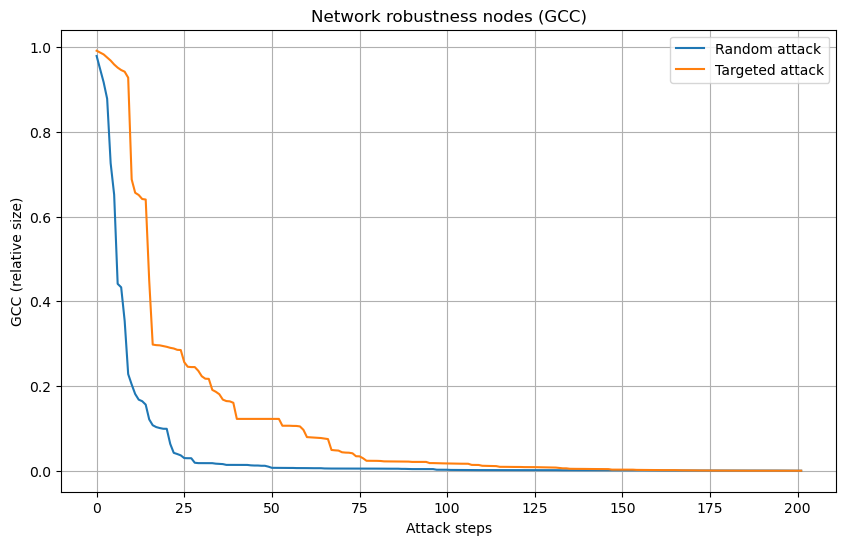

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(gcc_random, label="Random attack")
plt.plot(gcc_target, label="Targeted attack")

plt.xlabel("Attack steps")
plt.ylabel("GCC (relative size)")
plt.title("Node removal robustness (GCC)")

plt.legend()
plt.grid()

plt.show()

In [127]:
random_edges = list(G.edges())
random.shuffle(random_edges)

edge_bet = nx.edge_betweenness_centrality(G, k=100)

target_edges = sorted(
    edge_bet,
    key=edge_bet.get,
    reverse=True
)

In [129]:
def simulate_edge_attack(G, edges, step=50):
    
    G_temp = G.copy()

    gcc_curve = []

    for i in range(0, len(edges), step):

        for e in edges[i:i+step]:
            if G_temp.has_edge(*e):
                G_temp.remove_edge(*e)

        gcc_curve.append(measure_gcc(G_temp))

    return gcc_curve

gcc_random = simulate_edge_attack(G_london_damaged, random_edges)
gcc_target = simulate_edge_attack(G_london_damaged, target_edges)

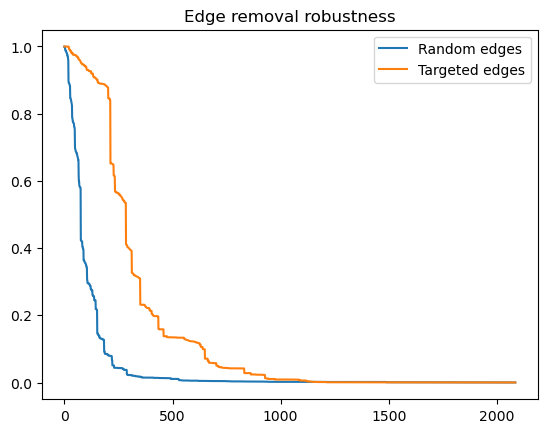

In [130]:
plt.plot(gcc_random, label="Random edges")
plt.plot(gcc_target, label="Targeted edges")

plt.legend()
plt.title("Edge removal robustness")
plt.show()

## Test with shortest path available

In [133]:
import random
def avg_path(G, sample=100):
    nodes = list(G.nodes())
    if len(nodes) < 2:
        return 0

    sample = random.sample(nodes, min(sample, len(nodes)))

    total = 0
    count = 0

    for i in sample:
        sp = nx.single_source_shortest_path_length(G, i)
        for j in sample:
            if i != j and j in sp:
                total += sp[j]
                count += 1

    return total / count if count else 0

baseline_path = avg_path(G_london_damaged)

In [124]:
def simulate(G, nodes, step=50):
    
    G = G.copy()
    base = avg_path(G)

    out = []

    for i in range(0, len(nodes), step):

        for n in nodes[i:i+step]:
            if n in G:
                G.remove_node(n)

        out.append(avg_path(G) / base)

    return out

random_curve = simulate(G_london, random_nodes)
target_curve = simulate(G_london, target)

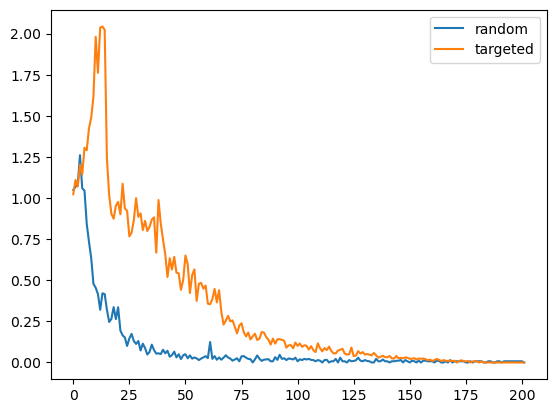

In [ ]:
plt.plot(random_curve, label="random")
plt.plot(target_curve, label="targeted")
plt.legend()
plt.title("Node removal impact on shortest path")
plt.show()

In [134]:
def simulate_edge_path(G, edges, step=50):
    
    G_temp = G.copy()

    curve = []

    for i in range(0, len(edges), step):

        for e in edges[i:i+step]:
            if G_temp.has_edge(*e):
                G_temp.remove_edge(*e)

        curve.append(
            avg_path(G_temp) / baseline_path
        )

    return curve

path_random = simulate_edge_path(G_london_damaged, random_edges)
path_target = simulate_edge_path(G_london_damaged, target_edges)

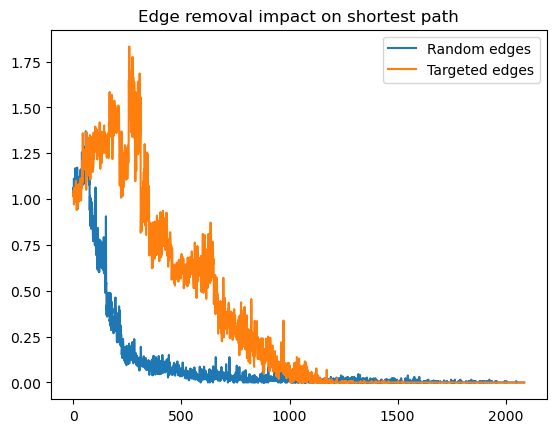

In [135]:
plt.plot(path_random, label="Random edges")
plt.plot(path_target, label="Targeted edges")

plt.legend()
plt.title("Edge removal impact on shortest path")
plt.show()

# Train movement data

In [ ]:
movement1 = "data/4E24_TRUST2.csv"
df_movement_first = pd.read_csv(movement1)

In [ ]:
df_movement_first.head()

In [ ]:
df_movement_first.columns

In [ ]:
# On crée un ensemble (set) de tous les STANOX présents dans ton graphe de Londres
# On utilise un set car la recherche est beaucoup plus rapide qu'avec une liste
stanox_london = {
    str(d['stanox']).zfill(5) 
    for n, d in G_london.nodes(data=True) 
    if 'stanox' in d and pd.notna(d['stanox'])
}

print(f"Nombre de STANOX uniques dans G_london : {len(stanox_london)}")

In [ ]:
# 1. On s'assure que la colonne loc_stanox est au bon format (String, 5 chiffres)
df_movement_first['loc_stanox'] = df_movement_first['loc_stanox'].astype(str).str.strip().str.zfill(5)

# 2. On ne garde que les lignes dont le STANOX est dans notre liste londonienne
df_movements_london = df_movement_first[df_movement_first['loc_stanox'].isin(stanox_london)].copy()

# 3. Résultat
print(f"Mouvements initiaux : {len(df_movement_first)}")
print(f"Mouvements à Londres : {len(df_movements_london)}")
print(f"Nombre de trains uniques restant : {df_movements_london['train_id'].nunique()}")